# **Tiền Xử Lý & Phân Tích Nội Dung Văn Bản**

## Tổng quan bộ dữ liệu
Trong phần này, chúng tôi thực hiện **tiền xử lý và phân tích nội dung văn bản** từ bộ dữ liệu `youtube_shorts_randomized.csv`. Dữ liệu thu thập từ **YouTube Shorts** trong khoảng thời gian **11/2024–9/2025**, bao gồm các thông tin về video, tương tác, hashtag và chủ đề.

**Thông tin cột dữ liệu và kiểu dữ liệu**

| Cột            | Kiểu dữ liệu   | Mô tả                                                                 |
|----------------|---------------|----------------------------------------------------------------------|
| video_id       | string        | Mã định danh duy nhất cho video                                       |
| title          | string        | Tiêu đề video                                                         |
| category       | string        | Danh mục chủ đề video                                                 |
| duration       | string/PT     | Thời lượng video (định dạng ISO 8601, ví dụ `PT28S`)                 |
| views          | int           | Số lượt xem                                                          |
| likes          | int           | Số lượt thích                                                        |
| comments       | int           | Số bình luận                                                         |
| hashtags       | string        | Các hashtag liên quan đến video                                      |
| publish_date   | datetime      | Ngày và giờ đăng video (ISO 8601)                                    |
| topic          | string        | Chủ đề phân loại (dựa trên tiêu đề hoặc phân loại tự động)           |
| channel_title  | string        | Tên kênh YouTube                                                      |
| subscribers    | int           | Số người đăng ký kênh  

## **1. Chuẩn Bị Môi Trường Và Dữ Liệu**


In [ ]:
!pip install langdetect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=9b482383095e87d09c0b7d728d581b079066efe4e55b5a6158a0037061e81752
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00


In [ ]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.7 MB/s eta 0:00:00


In [ ]:
!pip install isodate

In [ ]:
import pandas as pd
import numpy as np
import re
import isodate
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import nltk

In [ ]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
df = pd.read_csv("youtube_shorts_vietnam.csv")


In [ ]:
df.info()
df.describe()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2385 entries, 0 to 2384
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video_id       2385 non-null   object
 1   title          2385 non-null   object
 2   category       2385 non-null   object
 3   duration       2385 non-null   object
 4   views          2385 non-null   int64 
 5   likes          2385 non-null   int64 
 6   comments       2385 non-null   int64 
 7   hashtags       2385 non-null   object
 8   publish_date   2385 non-null   object
 9   topic          2385 non-null   object
 10  channel_title  2385 non-null   object
 11  subscribers    2385 non-null   int64 
dtypes: int64(4), object(8)
memory usage: 223.7+ KB


,video_id,title,category,duration,views,likes,comments,hashtags,publish_date,topic,channel_title,subscribers
0,PvAtObqiFLY,Nhảy cùng cô dâu/kỳ kỳ tv & Family,People & Blogs,PT28S,12799187,88014,184,#shortvideo,2025-03-18T10:43:14Z,nhảy,Kỳ kỳ tv & Family,3210000
1,SKtsqm_Chv4,Chuyện rửa chén ngày Tết hài hước,Comedy,PT53S,25093840,350224,320,#Shorts,2023-01-08T11:30:15Z,hài hước,Hy và Ni,1620000
2,Y1y4NRd474o,Mẹo vặt cuộc sống,People & Blogs,PT42S,87159,1252,4,#meonhothuvi,2025-02-27T05:00:32Z,mẹo vặt,Mẹo nhỏ thú vị,275000
3,b7bTyvVUZCM,Những khoảnh khắc hài hước của Conan🤣,People & Blogs,PT17S,80715,2168,22,"#amuro,#haibara,#akai,#conan",2025-03-21T08:29:20Z,hài hước,Kerlix,9670
4,ii0aGksKFR0,[Chee bủm review] Trải nghiệm ẩm thực Hàng Mã ...,Entertainment,PT47S,194147,10586,42,#shorts,2023-09-28T12:00:37Z,ẩm thực,LKH TV,88700


## **2. Tiền Xử Lý Dữ Liệu**

### **2.1. Data Cleaning cơ bản / Chuẩn hóa dữ liệu số và cột**

#### **a) Chuyển kiểu dữ liệu**
Mục đích
- Cột `publish_date` có kiểu dữ liệu hiện tại là object, cần chuyển sang datetime để phân tích thời gian.
- Cột `duration` đang được biểu diễn dưới dạng ISO 8601 và nên chuyển sang số giây để phân tích

In [ ]:

# Chuyển publish_date sang datetime
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')

# Chuyển duration sang số giây
df['duration_seconds'] = df['duration'].apply(lambda x: isodate.parse_duration(x).total_seconds())


#### **b) Xử lý trùng lặp**

Mục đích:

- `video_id` là duy nhất → loại bỏ các bản ghi trùng để tránh phân tích bị sai lệch.

In [ ]:
# Kiểm tra trùng lặp
print("Số video_id trùng lặp:", df['video_id'].duplicated().sum())

# Loại bỏ video_id trùng
df = df.drop_duplicates(subset=['video_id'])

Số video_id trùng lặp: 0


#### **c) Xử lý dữ liệu số bất hợp lệ**
Mục đích:

- Các cột số: `views`, `likes`, `comments`, `subscribers` không nên có giá trị âm.

- Đảm bảo các phân tích thống kê và trực quan dữ liệu chính xác.

In [ ]:
numeric_cols = ['views', 'likes', 'comments', 'subscribers']

for col in numeric_cols:
    # Loại bỏ giá trị âm
    df = df[df[col] >= 0]


### **2.2. Tiền xử lý văn bản**

- Làm sạch văn bản: chuyển chữ thường, loại bỏ ký tự đặc biệt, emoji, URL, khoảng trắng thừa, xử lý missing values

- Stopwords: loại bỏ stopwords tiếng Anh (NLTK)

- Tokenization: tách từ title và topic, tách hashtags thành list

- Chuẩn hóa văn bản: stemming (PorterStemmer), lemmatization (WordNetLemmatizer), lưu kết quả vào cột mới (title_clean, hashtags_list, topic_clean)

- Lọc dữ liệu tiếng Anh: phát hiện ngôn ngữ (langdetect), tạo DataFrame con df_en

#### **a) Chuyển chữ thường**

Mục đích:

- Giúp tất cả từ được thống nhất, tránh cùng một từ nhưng chữ hoa/chữ thường bị coi là khác nhau.

- Ví dụ: "YouTube" và "youtube" → cùng 1 từ.

In [ ]:
df['title_clean'] = df['title'].str.lower()
df['hashtags_clean'] = df['hashtags'].str.lower()
df['topic'] = df['topic'].str.lower()
df['channel_title'] = df['channel_title'].str.lower()


#### **b) Xóa khoảng trắng thừa**

Mục đích:

- Loại bỏ khoảng trắng đầu/cuối và nhiều khoảng trắng liên tiếp giữa các từ.

- Giúp văn bản gọn gàng, chuẩn cho tokenization.

In [ ]:
df['title_clean'] = df['title_clean'].str.strip()
df['title_clean'] = df['title_clean'].str.replace(r'\s+', ' ', regex=True)

df['hashtags_clean'] = df['hashtags_clean'].str.strip()
df['hashtags_clean'] = df['hashtags_clean'].str.replace(r'\s+', ' ', regex=True)



#### **c) Loại bỏ ký tự đặc biệt**

Mục đích:

- Giữ lại chỉ chữ, số, và ký tự đặc biệt quan trọng như # trong hashtags.

- Giúp NLP hoạt động chính xác (không bị nhiễu bởi các ký tự lạ).

In [ ]:
def remove_special_chars(text):
    if pd.isnull(text):
        return ""
    # Chỉ giữ chữ, số, khoảng trắng và #
    text = re.sub(r'[^\w\s#]', '', text)
    return text

df['title_clean'] = df['title_clean'].apply(remove_special_chars)
df['hashtags_clean'] = df['hashtags_clean'].apply(remove_special_chars)
df['channel_title'] = df['channel_title'].apply(remove_special_chars)


#### **d) Xóa các giá trị rỗng hoặc Nul**

Mục đích:

- Đảm bảo dữ liệu không có giá trị trống gây lỗi cho các bước NLP tiếp theo

In [ ]:
df['title_clean'] = df['title_clean'].replace('', 'unknown')
df['hashtags_clean'] = df['hashtags_clean'].replace('', 'none')


#### **e) Loại bỏ URL và Emoji**

Mục đích:

- URL: Loại bỏ link vì chúng không mang ý nghĩa ngôn ngữ trực tiếp cho phân tích NLP.

- Emoji: Loại bỏ vì chúng có thể gây lỗi khi tokenization hoặc embedding.

In [ ]:
def remove_url_emoji(text):
    if pd.isnull(text):
        return ""
    # Loại bỏ URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Loại bỏ emoji
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags
                           "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    return text

df['title_clean'] = df['title_clean'].apply(remove_url_emoji)
df['hashtags_clean'] = df['hashtags_clean'].apply(remove_url_emoji)
df['channel_title']=df['channel_title'].apply(remove_url_emoji)


#### **g) Xử lý hashtags_clean: tách hashtag**

In [ ]:
import re

def parse_hashtags(s):
    """Tách hashtag thành danh sách từ khóa"""
    if not isinstance(s, str) or not s.strip():
        return []
    # Tách theo dấu # (đảm bảo các hashtag liền nhau được tách riêng)
    tags = re.split(r'#', s.lower())
    # Loại bỏ phần rỗng và khoảng trắng dư
    tags = [t.strip() for t in tags if t.strip()]
    return tags

# Áp dụng cho DataFrame
df['hashtag_list'] = df['hashtags_clean'].apply(parse_hashtags)
df['n_hashtags'] = df['hashtag_list'].apply(len)

# Hiển thị kết quả mẫu
df[['hashtags_clean', 'hashtag_list', 'n_hashtags']].head()


,hashtags_clean,hashtag_list,n_hashtags
0,#shortvideo,[shortvideo],1
1,#shorts,[shorts],1
2,#meonhothuvi,[meonhothuvi],1
3,#amuro#haibara#akai#conan,"[amuro, haibara, akai, conan]",4
4,#shorts,[shorts],1


#### Gán nhãn Ngôn ngữ

In [ ]:
# Cài đặt thư viện nếu bạn chưa có:
# !pip install langdetect

from langdetect import detect, LangDetectException
import pandas as pd

# Hàm phát hiện ngôn ngữ an toàn (tránh lỗi khi gặp chuỗi rỗng hoặc không hợp lệ)
def detect_language(text):
    if pd.isnull(text) or not text.strip():
        return "unknown"  # Trả về 'unknown' nếu dữ liệu rỗng

    try:
        return detect(text)
    except LangDetectException:
        # Lỗi này thường xảy ra khi chuỗi quá ngắn hoặc chỉ chứa ký hiệu
        return "unknown"

# ---- Gán nhãn Ngôn ngữ ----

# Áp dụng hàm phát hiện ngôn ngữ vào cột 'title_clean'
# (Giả định 'title_clean' là cột văn bản đã được làm sạch cơ bản)
df["lang"] = df["title_clean"].apply(detect_language)

# In ra kết quả thống kê để xem tỷ lệ ngôn ngữ
print("Kết quả phân loại ngôn ngữ:")
print(df["lang"].value_counts(normalize=True) * 100) # Hiển thị dưới dạng %

# (Tùy chọn) In ra số lượng cụ thể
# print(df["lang"].value_counts())

Kết quả phân loại ngôn ngữ:
lang
vi    98.951782
en     0.419287
pt     0.167715
tl     0.083857
fr     0.083857
ca     0.083857
et     0.041929
es     0.041929
sk     0.041929
id     0.041929
af     0.041929
Name: proportion, dtype: float64


In [ ]:
# Lọc DataFrame, chỉ giữ lại những hàng có cột 'lang' là 'vi'
df_vietnamese = df[df['lang'] == 'vi'].copy()

# In ra để kiểm tra
print(f"Số video ban đầu: {len(df)}")
print(f"Số video tiếng Việt sau khi lọc: {len(df_vietnamese)}")
print(df_vietnamese['lang'].value_counts())

Số video ban đầu: 2385
Số video tiếng Việt sau khi lọc: 2360
lang
vi    2360
Name: count, dtype: int64


#### **f) Xử lý title_clean: Tokenization + Stopwords + Clean text**

In [ ]:
# (Giả định bạn đã có stopwords_vi - nếu chưa, hãy dán lại từ file gốc)
stopwords_vi = set([
    "a", "à", "á", "ào", "ạ", "ả", "ã", "anh", "chị", "em", "anh_ấy", "chị_ấy",
    "bà", "bác", "bạn", "bởi", "bị", "bên", "bây_giờ", "bao_giờ", "bấy_giờ",
    "bấy_nhiêu", "bất_kỳ", "bất_cứ", "bất_chợt", "cả", "các", "cái", "cần",
    "càng", "chỉ", "chiếc", "cho", "chứ", "chưa", "chuyện", "có", "có_thể",
    "có_lẽ", "có_thật", "cứ", "của", "cũng", "đã", "đang", "đây",
    "để", "đến", "đều", "đi", "do", "dưới", "đó", "được", "gì", "khi", "không",
    "là", "lại", "lên", "lúc", "mà", "mỗi", "một", "một_cách", "này", "nên",
    "nếu", "ngay", "người", "nhau", "nhé", "nhưng", "như", "những", "nơi",
    "nào", "nữa", "phải", "qua", "quá", "ra", "rằng", "rất", "rồi", "sau",
    "sẽ", "so", "sự", "tại", "thì", "thật", "theo", "thế", "thường", "trên",
    "trong", "trước", "từ", "từng", "và", "vẫn", "vào", "vì", "việc", "với",
    "vừa", "vậy", "vẫn_còn", "đây", "đấy", "đó", "được", "điều", "gì", "ai",
    "gần", "xa", "nào", "nấy", "hết", "hơn", "ít", "nhiều", "lắm", "mọi",
    "mình", "ta", "tôi", "chúng_ta", "chúng_tôi", "họ", "các_bạn", "nó",
    "vì_vậy", "vì_thế", "bởi_vì", "do_vậy", "tuy_nhiên", "song", "hoặc",
    "hay", "đều", "nên", "vẫn", "dù", "mặc_dù", "mà", "nhưng", "trong_khi",
    "nếu", "giả_sử", "thì", "và", "cũng_vậy", "đồng_thời", "vì_thế", "do_đó",
    "thế_nên", "nhờ_vậy", "cho_dù", "bất_chấp", "miễn_là"
])

# Cài đặt nếu bạn chưa có
# !pip install underthesea
from underthesea import word_tokenize

def tokenize_vi(text):
    if not isinstance(text, str) or not text.strip():
        return []
    tokens = word_tokenize(text)
    # Loại bỏ stopword và token ngắn (<= 1 ký tự)
    return [t for t in tokens if t.lower() not in stopwords_vi and len(t) > 1]

# ---- Áp dụng cho DataFrame Tiếng Việt ----
print("Bắt đầu Tokenization tiếng Việt...")

# Áp dụng cho DataFrame đã lọc
df_vietnamese['title_tokens'] = df_vietnamese['title_clean'].apply(tokenize_vi)
df_vietnamese['title_clean_text'] = df_vietnamese['title_tokens'].apply(lambda x: " ".join(x))

print("Hoàn thành!")

# Kiểm tra kết quả
print(df_vietnamese[['title_clean', 'title_tokens', 'title_clean_text']].head())

Bắt đầu Tokenization tiếng Việt...
Hoàn thành!
                                         title_clean  \
0                   nhảy cùng cô dâukỳ kỳ tv  family   
1                  chuyện rửa chén ngày tết hài hước   
2                                  mẹo vặt cuộc sống   
3               những khoảnh khắc hài hước của conan   
4  chee bủm review trải nghiệm ẩm thực hàng mã  l...   

                                        title_tokens  \
0             [nhảy, cùng, cô, dâukỳ, kỳ tv, family]   
1                   [rửa, chén, ngày, tết, hài hước]   
2                              [mẹo, vặt, cuộc sống]   
3                     [khoảnh khắc, hài hước, conan]   
4  [chee, bủm, review, trải nghiệm, ẩm thực, hàng...   

                                    title_clean_text  
0                    nhảy cùng cô dâukỳ kỳ tv family  
1                         rửa chén ngày tết hài hước  
2                                  mẹo vặt cuộc sống  
3                         khoảnh khắc hài hước conan  
4  c



#### **h) Chuẩn hóa cột category sang tiếng Việt**

In [ ]:
# Display unique values in the 'category' column
print(df_vietnamese['category'].unique())

['People & Blogs' 'Comedy' 'Entertainment' 'Howto & Style' 'Education'
 'Music' 'Science & Technology' 'Gaming' 'Sports' 'News & Politics'
 'Travel & Events' 'Film & Animation' 'Autos & Vehicles' 'Pets & Animals'
 '29']


In [ ]:
import pandas as pd

# Ánh xạ tiếng Anh → tiếng Việt
category_map = {
    "People & Blogs": "Đời sống",
    "Entertainment": "Giải trí",
    "Music": "Âm nhạc",
    "Howto & Style": "Mẹo vặt & Phong cách",
    "Gaming": "Trò chơi",
    "Travel & Events": "Du lịch & Sự kiện",
    "Education": "Giáo dục",
    "Comedy": "Hài hước",
    "Science & Technology": "Khoa học & Công nghệ",
    "Film & Animation": "Phim & Hoạt hình",
    "Pets & Animals": "Động vật",
    "News & Politics": "Tin tức & Chính trị",
    "Autos & Vehicles": "Xe cộ",
    "Sports": "Thể thao",
    "29": "Khác"  # dữ liệu lỗi
}

# Tạo cột mới category_vi chứa tên tiếng Việt
df_vietnamese["category_vi"] = df_vietnamese["category"].map(category_map).fillna("Khác")

# Hiển thị danh sách các giá trị chuẩn hóa
df_vietnamese[["category", "category_vi"]].drop_duplicates().reset_index(drop=True)


,category,category_vi
0,People & Blogs,Đời sống
1,Comedy,Hài hước
2,Entertainment,Giải trí
3,Howto & Style,Mẹo vặt & Phong cách
4,Education,Giáo dục
5,Music,Âm nhạc
6,Science & Technology,Khoa học & Công nghệ
7,Gaming,Trò chơi
8,Sports,Thể thao
9,News & Politics,Tin tức & Chính trị


In [ ]:
import re

def remove_channel_from_title(row):
    title = str(row.get('title_clean', '')).lower().strip()
    channel = str(row.get('channel_title', '')).lower().strip()
    if not title or not channel:
        return title

    # Chuẩn hóa tên kênh để so khớp ổn định
    channel_clean = re.sub(r'[^a-zA-ZÀ-ỹ0-9\s]', ' ', channel)
    channel_clean = re.sub(r'\s+', ' ', channel_clean).strip()

    if channel_clean and channel_clean in title:
        pattern = re.escape(channel_clean)
        title = re.sub(pattern, ' ', title)
        title = re.sub(r'\s+', ' ', title).strip()
    return title

df_vietnamese['title_clean'] = df_vietnamese.apply(remove_channel_from_title, axis=1)

# Kiểm tra nhanh
df_vietnamese[['channel_title','title_clean']].head()


,channel_title,title_clean
0,kỳ kỳ tv family,nhảy cùng cô dâukỳ kỳ tv family
1,hy và ni,chuyện rửa chén ngày tết hài hước
2,mẹo nhỏ thú vị,mẹo vặt cuộc sống
3,kerlix,những khoảnh khắc hài hước của conan
4,lkh tv,chee bủm review trải nghiệm ẩm thực hàng mã


In [ ]:
# Hiển thị kết quả các cột mới
df_vietnamese.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2360 entries, 0 to 2384
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   video_id          2360 non-null   object             
 1   title             2360 non-null   object             
 2   category          2360 non-null   object             
 3   duration          2360 non-null   object             
 4   views             2360 non-null   int64              
 5   likes             2360 non-null   int64              
 6   comments          2360 non-null   int64              
 7   hashtags          2360 non-null   object             
 8   publish_date      2360 non-null   datetime64[ns, UTC]
 9   topic             2360 non-null   object             
 10  channel_title     2360 non-null   object             
 11  subscribers       2360 non-null   int64              
 12  duration_seconds  2360 non-null   float64            
 13  title_cl

In [ ]:
# Lưu DataFrame thành file CSV
# index=False để không lưu cột index (số thứ tự) của pandas
df_vietnamese.to_csv('youtube_data_vietnamese.csv', index=False)

print("Đã lưu file thành công!")

Đã lưu file thành công!


In [ ]:
from google.colab import files

# Ra lệnh tải file
files.download('youtube_data_vietnamese.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **3. Phân Tích Nội Dung Cơ Bản**

- Tần suất từ khóa và hashtag
- Word Cloud
- Phân tích xu hướng theo thời gian
- Phân tích theo topic

In [ ]:
# 1.1. Phân tích từ khóa trong title_clean_text
from collections import Counter

# Gộp tất cả token từ các title
all_tokens = [token for sublist in df['title_tokens'] for token in sublist]
token_freq = Counter(all_tokens)

# Top 20 từ khóa phổ biến nhất
top_tokens = token_freq.most_common(10)
print("Top 10 từ khóa trong tiêu đề:")
for word, freq in top_tokens:
    print(f"{word}: {freq}")

# 1.2. Phân tích hashtag phổ biến
all_hashtags = [tag for sublist in df['hashtag_list'] for tag in sublist]
hashtag_freq = Counter(all_hashtags)

# Top 20 hashtag phổ biến nhất
top_hashtags = hashtag_freq.most_common(10)
print("\nTop 10 hashtag phổ biến:")
for tag, freq in top_hashtags:
    print(f"{tag}: {freq}")

Top 20 từ khóa trong tiêu đề:
học tập: 247
mẹo: 229
du lịch: 220
vặt: 204
hài hước: 170
ăn: 162
giải trí: 160
ẩm thực: 132
nhảy: 112
cười: 102
đồ dùng: 99
cuộc sống: 97
nhất: 93
đường phố: 88
cùng: 80
âm nhạc: 79
ấn độ: 77
review: 76
làm: 72
téc rốn: 71

Top 20 hashtag phổ biến:
shorts: 1013
funny: 312
food: 162
giaitri: 130
haihuoc: 112
mukbang: 91
trending: 79
meovat: 79
shortvideo: 78
viral: 77
hài: 74
okvipbepnhaminh: 71
okvip: 71
meovatcuocsong: 70
review: 61
dance: 56
xuhuong: 53
tiktok: 50
giảitrí: 49
tips: 43


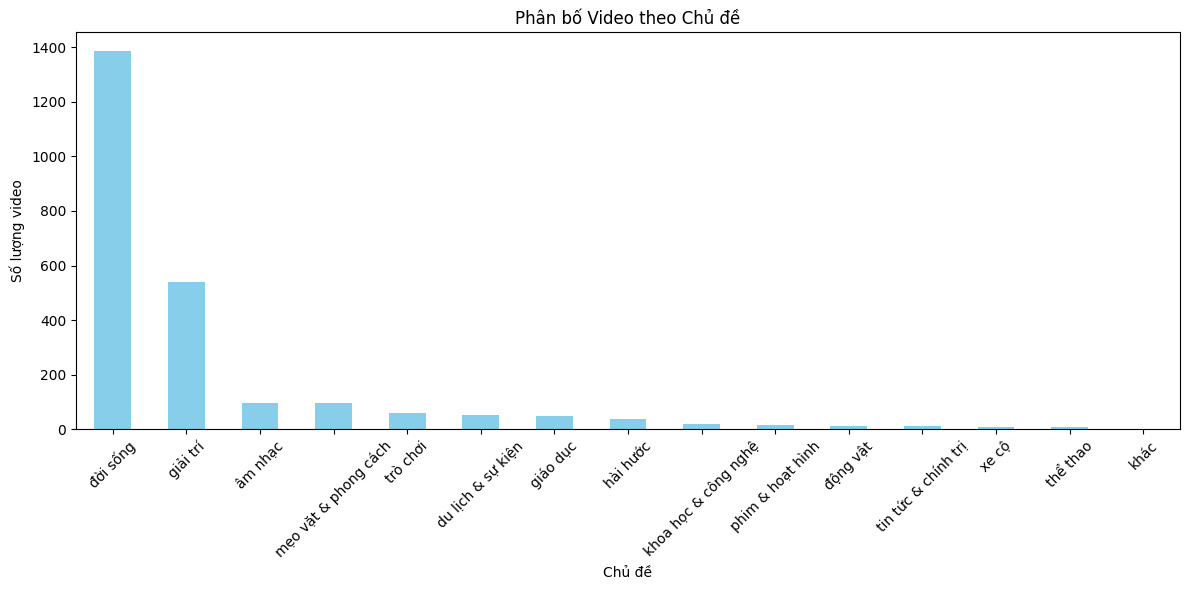

Tương tác trung bình theo chủ đề:
                            views      likes  comments
topic_clean                                           
hài hước             9,197,643.14 127,099.68    369.43
giải trí             6,432,615.43  82,832.84    561.39
âm nhạc              5,732,369.96  41,682.32    531.75
xe cộ                4,868,721.38  32,213.62     76.00
khoa học & công nghệ 4,507,409.37 132,102.05    906.37
đời sống             4,058,977.80  48,685.10    388.15
động vật             3,173,218.33  26,707.17     75.75
trò chơi             2,810,836.91  21,054.41    168.10
thể thao             2,018,634.83  14,869.00     73.50
phim & hoạt hình     1,476,536.20  16,992.27    275.67
giáo dục               736,460.35  11,026.02     59.84
tin tức & chính trị    709,455.60   9,018.30    175.60
mẹo vặt & phong cách   614,673.17  10,214.53     60.22
du lịch & sự kiện      120,766.29   1,710.12     19.82
khác                    11,130.50     112.00      2.50


In [ ]:
# 3.1. Phân bố video theo chủ đề
topic_counts = df['topic_clean'].value_counts()

plt.figure(figsize=(12, 6))
topic_counts.plot(kind='bar', color='skyblue')
plt.title('Phân bố Video theo Chủ đề')
plt.xlabel('Chủ đề')
plt.ylabel('Số lượng video')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3.2. Tương tác trung bình theo chủ đề
topic_engagement = df.groupby('topic_clean').agg({
    'views': 'mean',
    'likes': 'mean',
    'comments': 'mean'
}).round(2)

print("Tương tác trung bình theo chủ đề:")
print(topic_engagement.sort_values('views', ascending=False))

In [ ]:
# Trên Google Colab, tải font trực tiếp
!wget -q "https://fonts.google.com/download?family=Noto%20Sans" -O noto_sans.zip
!unzip -q -o noto_sans.zip -d noto_sans/

[noto_sans.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of noto_sans.zip or
        noto_sans.zip.zip, and cannot find noto_sans.zip.ZIP, period.


Không tìm thấy font phù hợp

Đang tạo Word Cloud... Vui lòng đảm bảo `font_path` đã chính xác.


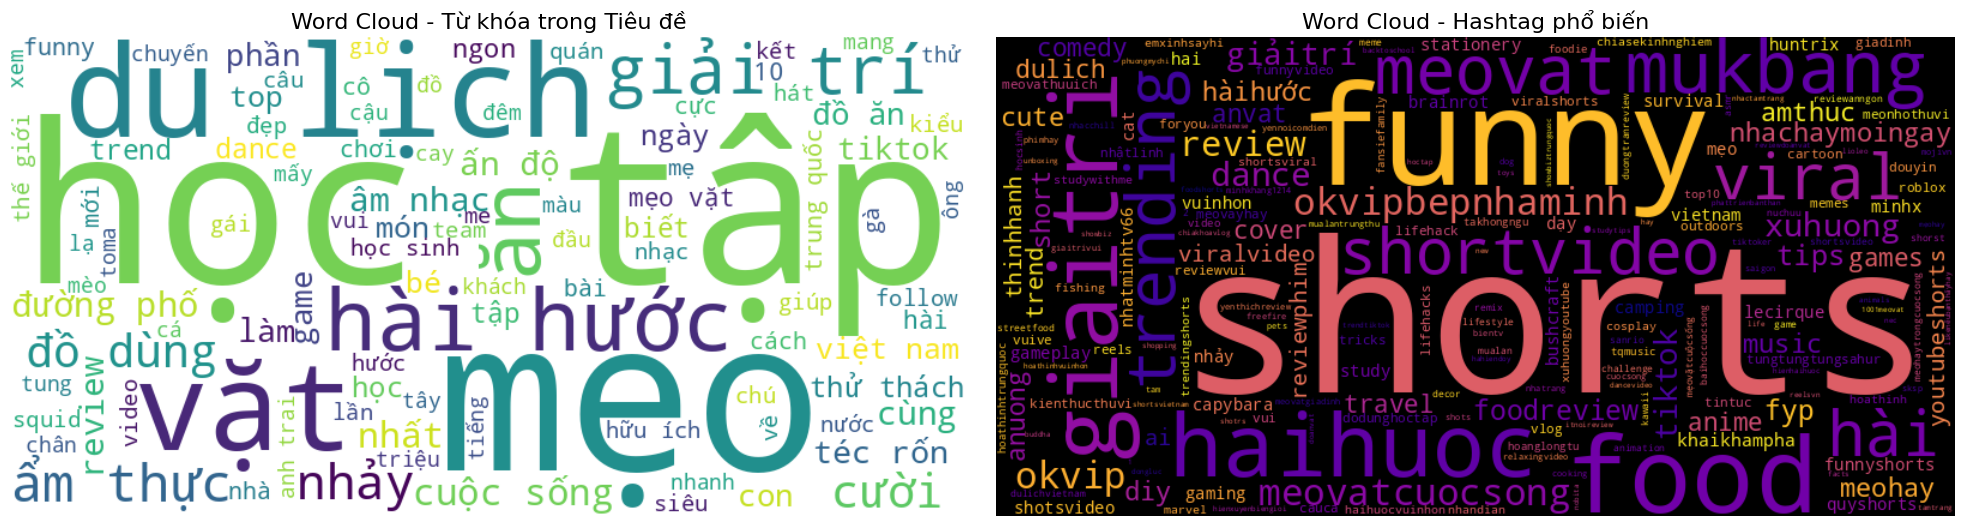

In [ ]:
import os
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Giả định: bạn đã có 2 dictionary là token_freq và hashtag_freq
# Giả định: bạn có thư mục 'noto_sans' chứa font

# --- Phần tìm font của bạn (giữ nguyên) ---
font_files = []
for root, dirs, files in os.walk('noto_sans'):
    for file in files:
        if file.endswith('.ttf') and 'Regular' in file:
            font_files.append(os.path.join(root, file))

if font_files:
    vietnamese_font = font_files[0]
    print(f"Sử dụng font: {vietnamese_font}")
else:
    vietnamese_font = None
    print("Không tìm thấy font phù hợp")
print("\nĐang tạo Word Cloud... Vui lòng đảm bảo `font_path` đã chính xác.")

# --- Phần tạo Word Cloud (đã chỉnh sửa) ---
try:
    # 1. Tạo Word Cloud cho Tiêu đề (NỀN TRẮNG)
    wc_title = WordCloud(
        width=800,
        height=400,
        background_color='white', # Nền trắng
        font_path=vietnamese_font,
        max_words=100,
        colormap='viridis'
    )
    wc_title.generate_from_frequencies(token_freq)

    # 2. Tạo Word Cloud cho Hashtag (NỀN ĐEN)
    wc_hashtag = WordCloud(
        width=800,
        height=400,
        background_color='black', # <-- THAY ĐỔI: Nền đen để khác biệt
        font_path=vietnamese_font,
        colormap='plasma'
    )
    wc_hashtag.generate_from_frequencies(hashtag_freq)

    # 3. Hiển thị cả hai Word Cloud (Cạnh nhau)
    # <-- THAY ĐỔI: Đổi (2, 1) thành (1, 2) và điều chỉnh figsize
    fig, axes = plt.subplots(1, 2, figsize=(20, 10)) # 1 hàng, 2 cột

    # Biểu đồ 1: Tiêu đề (Bên trái)
    axes[0].imshow(wc_title, interpolation='bilinear')
    axes[0].set_title('Word Cloud - Từ khóa trong Tiêu đề', fontsize=16)
    axes[0].axis('off')

    # Biểu đồ 2: Hashtag (Bên phải)
    axes[1].imshow(wc_hashtag, interpolation='bilinear')
    axes[1].set_title('Word Cloud - Hashtag phổ biến', fontsize=16)
    axes[1].axis('off')

    plt.tight_layout(pad=2)
    plt.show()

except Exception as e:
    print(f"Có lỗi xảy ra: {e}")
    if vietnamese_font is None:
        print("Lỗi có thể do 'vietnamese_font' đang là None. Vui lòng kiểm tra lại đường dẫn font.")

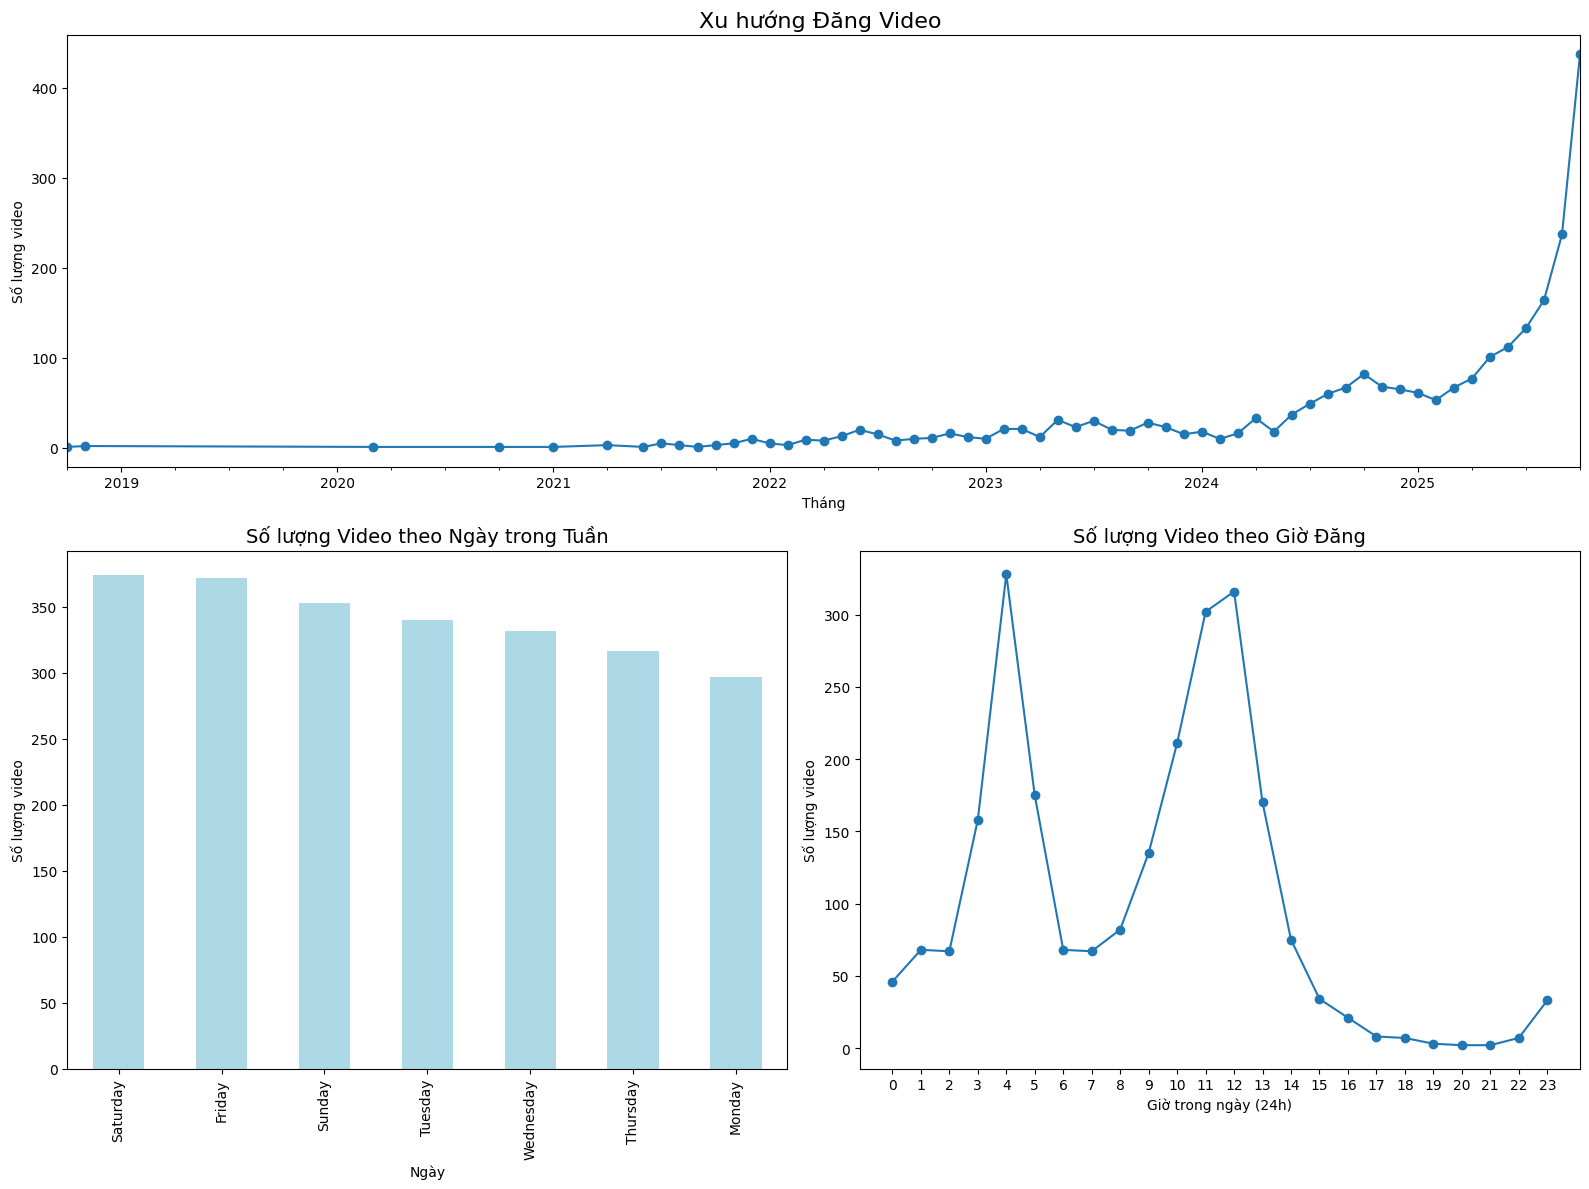

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Tạo figure
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2])  # 2 hàng, 2 cột, nửa trên cao hơn

# --- Biểu đồ 4.1: Xu hướng theo tháng (nửa trên, chiếm 2 cột)
ax0 = fig.add_subplot(gs[0, :])
monthly_trend.plot(kind='line', marker='o', ax=ax0)
ax0.set_title('Xu hướng Đăng Video ', fontsize=16)
ax0.set_xlabel('Tháng')
ax0.set_ylabel('Số lượng video')
ax0.grid(False)

# --- Biểu đồ 4.2: Video theo ngày trong tuần (nửa dưới, cột trái)
ax1 = fig.add_subplot(gs[1, 0])
day_counts.plot(kind='bar', color='lightblue', ax=ax1)
ax1.set_title('Số lượng Video theo Ngày trong Tuần', fontsize=14)
ax1.set_xlabel('Ngày')
ax1.set_ylabel('Số lượng video')
ax1.grid(False)

# --- Biểu đồ 4.3: Video theo giờ đăng (nửa dưới, cột phải)
ax2 = fig.add_subplot(gs[1, 1])
hour_counts.plot(kind='line', marker='o', ax=ax2)
ax2.set_title('Số lượng Video theo Giờ Đăng', fontsize=14)
ax2.set_xlabel('Giờ trong ngày (24h)')
ax2.set_ylabel('Số lượng video')
ax2.set_xticks(range(24))
ax2.grid(False)

plt.tight_layout()
plt.show()


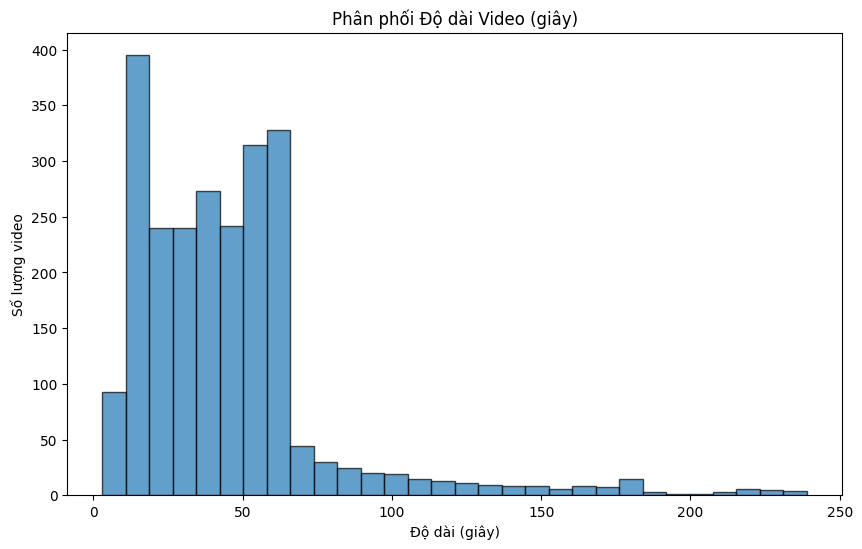

Tương quan giữa Độ dài video và Tương tác:
duration_seconds    1.00
views              -0.05
likes              -0.04
comments           -0.04
Name: duration_seconds, dtype: float64


In [ ]:
# 7.1. Phân phối độ dài video
plt.figure(figsize=(10, 6))
plt.hist(df['duration_seconds'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Phân phối Độ dài Video (giây)')
plt.xlabel('Độ dài (giây)')
plt.ylabel('Số lượng video')
plt.grid(False)
plt.show()

# 7.2. Tương quan giữa độ dài và tương tác
duration_corr = df[['duration_seconds', 'views', 'likes', 'comments']].corr()
print("Tương quan giữa Độ dài video và Tương tác:")
print(duration_corr['duration_seconds'])

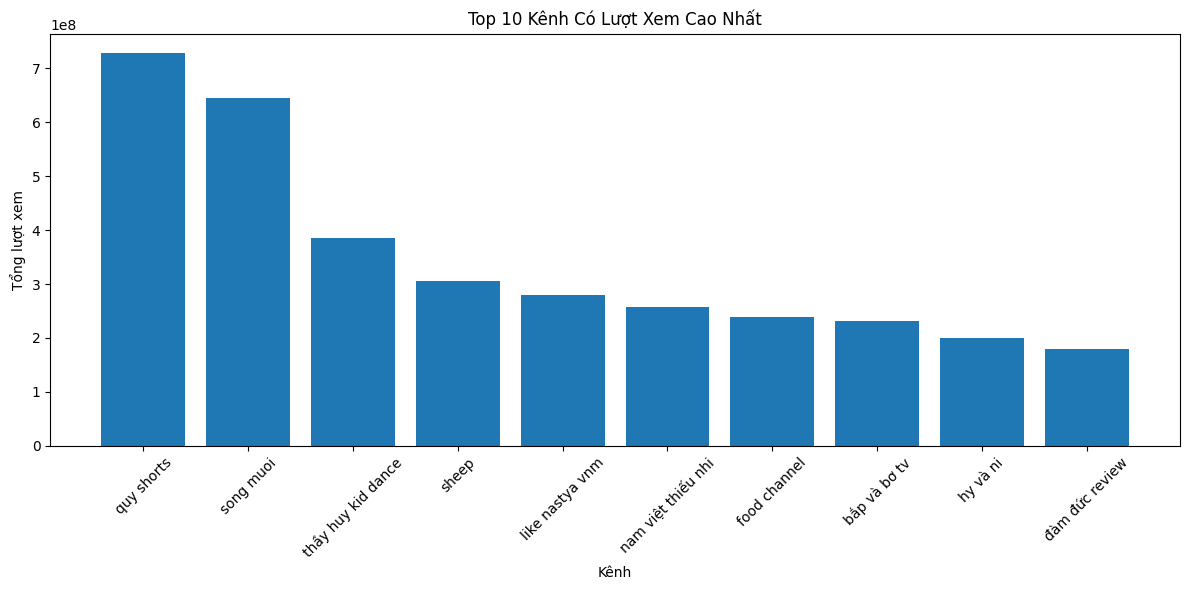

In [ ]:
# Tính hiệu suất kênh
channel_performance = df.groupby('channel_title').agg({
    'views': 'sum'
}).reset_index().rename(columns={'views': 'Tổng views'})

# Lấy Top 10 kênh có tổng lượt xem cao nhất
top_10_highest_views = channel_performance.sort_values('Tổng views', ascending=False).head(10)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.bar(top_10_highest_views['channel_title'], top_10_highest_views['Tổng views'])
plt.title('Top 10 Kênh Có Lượt Xem Cao Nhất')
plt.xlabel('Kênh')
plt.ylabel('Tổng lượt xem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
video_count = df.groupby('channel_title')['video_id'].count().reset_index()
video_count.columns = ['channel_title', 'Số video']
top_10_merged = top_10_highest_views.merge(video_count, on='channel_title')
top_10_merged.sort_values('Tổng views', ascending=False)


,channel_title,Tổng views,Số video
0,quy shorts,727257208,14
1,song muoi,644943443,1
2,thầy huy kid dance,386025160,26
3,sheep,305706672,18
4,like nastya vnm,279236547,1
5,nam việt thiếu nhi,257941317,2
6,food channel,238631303,3
7,bắp và bơ tv,232347983,2
8,hy và ni,199387952,11
9,đàm đức review,178919399,12


In [ ]:
top_10_merged['Views trung bình/video'] = top_10_merged['Tổng views'] / top_10_merged['Số video']
top_10_merged.sort_values('Views trung bình/video', ascending=False)


,channel_title,Tổng views,Số video,Views trung bình/video
1,song muoi,644943443,1,"644,943,443.00"
4,like nastya vnm,279236547,1,"279,236,547.00"
5,nam việt thiếu nhi,257941317,2,"128,970,658.50"
7,bắp và bơ tv,232347983,2,"116,173,991.50"
6,food channel,238631303,3,"79,543,767.67"
0,quy shorts,727257208,14,"51,946,943.43"
8,hy và ni,199387952,11,"18,126,177.45"
3,sheep,305706672,18,"16,983,704.00"
9,đàm đức review,178919399,12,"14,909,949.92"
2,thầy huy kid dance,386025160,26,"14,847,121.54"


In [ ]:
# 1) Tính thời lượng trung bình theo kênh
duration_avg = df.groupby('channel_title')['duration_seconds'].mean().reset_index()

# 2) Gộp vào bảng top 10 kênh (top_10_merged)
top_10_merged = top_10_merged.merge(duration_avg, on='channel_title')

# 3) Đổi tên cột cho rõ nghĩa
top_10_merged.rename(columns={'duration_seconds':'Thời lượng TB (giây)'}, inplace=True)

# 4) Làm đẹp bảng kết quả và hiển thị
pd.set_option('display.float_format', '{:,.2f}'.format)  # hiển thị số đẹp
print("Bảng Top 10 kênh có lượt xem cao nhất kèm thời lượng trung bình:")
print(top_10_merged)


Bảng Top 10 kênh có lượt xem cao nhất kèm thời lượng trung bình:
        channel_title  Tổng views  Số video  Views trung bình/video  \
0          quy shorts   727257208        14           51,946,943.43   
1           song muoi   644943443         1          644,943,443.00   
2  thầy huy kid dance   386025160        26           14,847,121.54   
3               sheep   305706672        18           16,983,704.00   
4     like nastya vnm   279236547         1          279,236,547.00   
5  nam việt thiếu nhi   257941317         2          128,970,658.50   
6        food channel   238631303         3           79,543,767.67   
7        bắp và bơ tv   232347983         2          116,173,991.50   
8            hy và ni   199387952        11           18,126,177.45   
9      đàm đức review   178919399        12           14,909,949.92   

   Thời lượng TB (giây)  
0                 13.79  
1                 13.00  
2                 26.58  
3                 53.83  
4                 14.00

In [ ]:
from collections import Counter

# Sử dụng cột 'hashtag_list' thay vì 'tags'
tags_top10 = df[df['channel_title'].isin(top_10_highest_views['channel_title'])]['hashtag_list']
tag_counter = Counter()

for hashtag_list_for_video in tags_top10.dropna(): # Lặp qua từng danh sách hashtag của mỗi video
    for tag in hashtag_list_for_video: # Lặp qua từng hashtag trong danh sách
        tag_counter[tag.strip()] += 1

tag_counter.most_common(20)

[('shorts', 62),
 ('trending', 23),
 ('huntrix', 14),
 ('quyshorts', 14),
 ('fyp', 8),
 ('damduc', 4),
 ('damducreview', 4),
 ('viral', 4),
 ('kpopdemonhunters', 4),
 ('food', 3),
 ('babywarriors', 2),
 ('namvietthieunhi', 2),
 ('phunganfamily', 1),
 ('songmuoi', 1),
 ('music', 1),
 ('xuhuong', 1),
 ('viralshorts', 1),
 ('tiktok', 1),
 ('satisfyingvideo', 1)]